In [9]:
"""
The most atomic way to train and run inference for a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.

@karpathy
"""

import os       # os.path.exists
import math     # math.log, math.exp
import random   # random.seed, random.choices, random.gauss, random.shuffle
random.seed(42) # Let there be order among chaos

# Let there be a Dataset `docs`: list[str] of documents (e.g. a list of names)
if not os.path.exists('input.txt'):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/karpathy/makemore/988aa59/names.txt'
    urllib.request.urlretrieve(names_url, 'input.txt')
docs = [line.strip() for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")

# Let there be a Tokenizer to translate strings to sequences of integers ("tokens") and back
uchars = sorted(set(''.join(docs))) # unique characters in the dataset become token ids 0..n-1
BOS = len(uchars) # token id for a special Beginning of Sequence (BOS) token
vocab_size = len(uchars) + 1 # total number of unique tokens, +1 is for BOS
print(f"vocab size: {vocab_size}")

# Let there be Autograd to recursively apply the chain rule through a computation graph
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads') # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # scalar value of this node calculated during forward pass
        self.grad = 0                   # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children       # children of this node in the computation graph
        self._local_grads = local_grads # local derivative of this node w.r.t. its children

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

# Initialize the parameters, to store the knowledge of the model
n_layer = 1     # depth of the transformer neural network (number of layers)
n_embd = 16     # width of the network (embedding dimension)
block_size = 16 # maximum context length of the attention window (note: the longest name is 15 characters)
n_head = 4      # number of attention heads
head_dim = n_embd // n_head # derived dimension of each head
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
params = [p for mat in state_dict.values() for row in mat for p in row] # flatten params into a single list[Value]
print(f"num params: {len(params)}")

# Define the model architecture: a function mapping tokens and parameters to logits over what comes next
# Follow GPT-2, blessed among the GPTs, with minor differences: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict['wte'][token_id] # token embedding
    pos_emb = state_dict['wpe'][pos_id] # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)] # joint token and position embedding
    x = rmsnorm(x) # note: not redundant due to backward pass via the residual connection

    for li in range(n_layer):
        # 1) Multi-head Attention block
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            attn_weights = softmax(attn_logits)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]
        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])
    return logits

# Let there be Adam, the blessed optimizer and its buffers
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params) # first moment buffer
v = [0.0] * len(params) # second moment buffer

# Repeat in sequence
num_steps = 1000 # number of training steps
for step in range(num_steps):

    # Take single document, tokenize it, surround it with BOS special token on both sides
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # Forward the token sequence through the model, building up the computation graph all the way to the loss
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        loss_t = -probs[target_id].log()
        losses.append(loss_t)
    loss = (1 / n) * sum(losses) # final average loss over the document sequence. May yours be low.

    # Backward the loss, calculating the gradients with respect to all model parameters
    loss.backward()

    # Adam optimizer update: update the model parameters based on the corresponding gradients
    lr_t = learning_rate * (1 - step / num_steps) # linear learning rate decay
    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
        m_hat = m[i] / (1 - beta1 ** (step + 1))
        v_hat = v[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}", end='\r')

# Inference: may the model babble back to us
temperature = 0.5 # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated names) ---")
for sample_idx in range(20):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    print(f"sample {sample_idx+1:2d}: {''.join(sample)}")

num docs: 32033
vocab size: 27
num params: 4192
step 1000 / 1000 | loss 2.6497
--- inference (new, hallucinated names) ---
sample  1: kamon
sample  2: ann
sample  3: karai
sample  4: jaire
sample  5: vialan
sample  6: karia
sample  7: yeran
sample  8: anna
sample  9: areli
sample 10: kaina
sample 11: konna
sample 12: keylen
sample 13: liole
sample 14: alerin
sample 15: earan
sample 16: lenne
sample 17: kana
sample 18: lara
sample 19: alela
sample 20: anton


## Adam Optimizer — Visual Walkthrough

Visualizing every quantity Adam computes, step by step.

```
m[i]   = beta1 * m[i] + (1 - beta1) * grad       # momentum (EMA of grad)
v[i]   = beta2 * v[i] + (1 - beta2) * grad²      # variance (EMA of grad²)
m_hat  = m[i] / (1 - beta1^t)                    # bias-corrected momentum
v_hat  = v[i] / (1 - beta2^t)                    # bias-corrected variance
lr_t   = lr × (1 - step/num_steps)               # decaying learning rate
update = lr_t × m_hat / (√v_hat + ε)             # final weight change
```


In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Exact microgpt hyperparameters
beta1 = 0.85
beta2 = 0.99
eps   = 1e-8
lr    = 0.01
N     = 1000  # num_steps

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
print("Setup done — beta1={}, beta2={}, lr={}, N={}".format(beta1, beta2, lr, N))


Setup done — beta1=0.85, beta2=0.99, lr=0.01, N=1000


## 1. Learning Rate Schedule

`lr_t = lr × (1 − step / num_steps)` — linear decay from 0.01 → ~0.

**Why decay?** Early: model knows nothing → take big exploratory steps.
Late: model converging → take tiny precise steps to avoid overshooting.


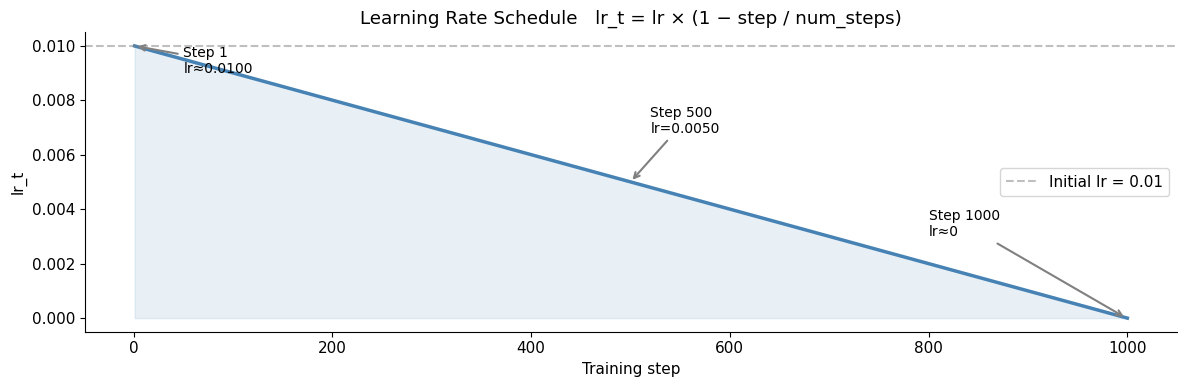

In [11]:
steps = np.arange(1, N + 1)
lr_schedule = lr * (1 - steps / N)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, lr_schedule, color='steelblue', linewidth=2.5)
ax.fill_between(steps, lr_schedule, alpha=0.12, color='steelblue')
ax.axhline(lr, color='gray', linestyle='--', alpha=0.5, label=f'Initial lr = {lr}')

ax.annotate(f'Step 1\nlr≈{lr_schedule[0]:.4f}',
            xy=(1, lr_schedule[0]), xytext=(50, lr_schedule[0] - 0.001),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.annotate(f'Step 500\nlr={lr_schedule[499]:.4f}',
            xy=(500, lr_schedule[499]), xytext=(520, lr_schedule[499] + 0.0018),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.annotate('Step 1000\nlr≈0',
            xy=(N-1, lr_schedule[-1]), xytext=(800, 0.003),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)

ax.set_xlabel('Training step')
ax.set_ylabel('lr_t')
ax.set_title('Learning Rate Schedule   lr_t = lr × (1 − step / num_steps)')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Bias Correction — Why m_hat and v_hat Exist

Both `m` and `v` are **initialized to 0**, not to the true gradient signal.
At step 1: `m[1] = 0.15 × grad` — massively underestimated.

Bias correction inflates the early values back to reality:
```
m_hat = m  / (1 − beta1^t)   →  at t=1: divide by (1−0.85) = 0.15 → inflates by ×6.7
v_hat = v  / (1 − beta2^t)   →  at t=1: divide by (1−0.99) = 0.01 → inflates by ×100!
```
After ~50 steps for `m` (β1=0.85) and ~500 steps for `v` (β2=0.99), the correction fades away.


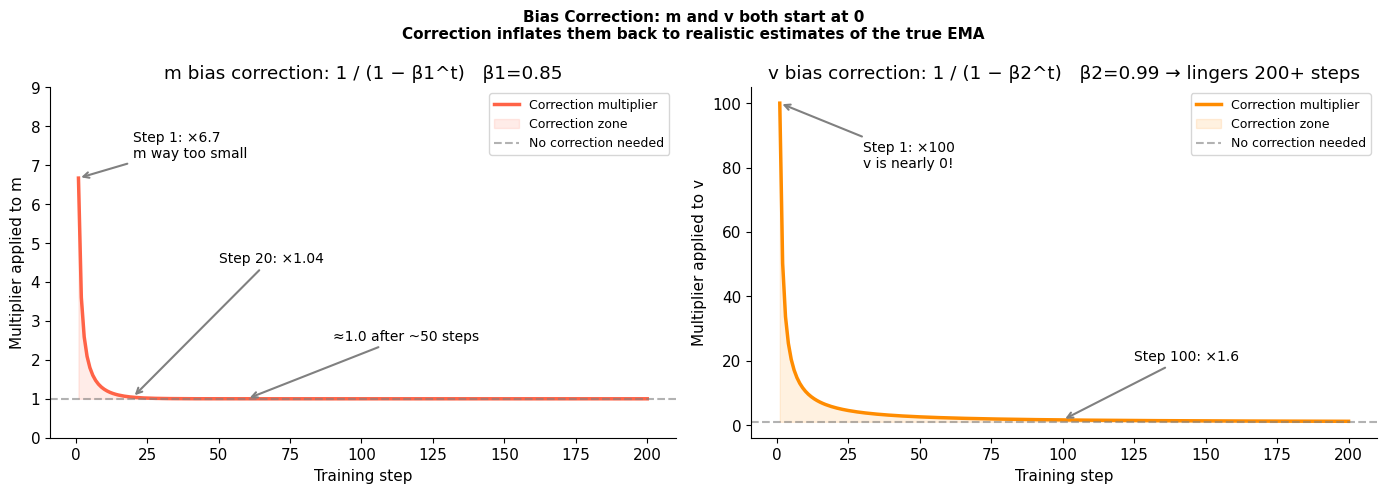

In [12]:
early = np.arange(1, 201)
bc_m  = 1 / (1 - beta1 ** early)
bc_v  = 1 / (1 - beta2 ** early)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── m bias correction ──
ax = axes[0]
ax.plot(early, bc_m, color='tomato', linewidth=2.5, label='Correction multiplier')
ax.fill_between(early, bc_m, 1, where=(bc_m > 1), alpha=0.12, color='tomato', label='Correction zone')
ax.axhline(1, color='gray', linestyle='--', alpha=0.6, label='No correction needed')
ax.set_ylim(0, 9)
ax.annotate(f'Step 1: ×{bc_m[0]:.1f}\nm way too small',
            xy=(1, bc_m[0]), xytext=(20, 7.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.annotate(f'Step 20: ×{bc_m[19]:.2f}',
            xy=(20, bc_m[19]), xytext=(50, 4.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.annotate('≈1.0 after ~50 steps',
            xy=(60, bc_m[59]), xytext=(90, 2.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.set_xlabel('Training step')
ax.set_ylabel('Multiplier applied to m')
ax.set_title(f'm bias correction: 1 / (1 − β1^t)   β1={beta1}')
ax.legend(fontsize=9)

# ── v bias correction ──
ax = axes[1]
ax.plot(early, bc_v, color='darkorange', linewidth=2.5, label='Correction multiplier')
ax.fill_between(early, bc_v, 1, where=(bc_v > 1), alpha=0.12, color='darkorange', label='Correction zone')
ax.axhline(1, color='gray', linestyle='--', alpha=0.6, label='No correction needed')
ax.annotate(f'Step 1: ×{bc_v[0]:.0f}\nv is nearly 0!',
            xy=(1, bc_v[0]), xytext=(30, 80),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.annotate(f'Step 100: ×{bc_v[99]:.1f}',
            xy=(100, bc_v[99]), xytext=(125, 20),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), fontsize=10)
ax.set_xlabel('Training step')
ax.set_ylabel('Multiplier applied to v')
ax.set_title(f'v bias correction: 1 / (1 − β2^t)   β2={beta2} → lingers 200+ steps')
ax.legend(fontsize=9)

plt.suptitle('Bias Correction: m and v both start at 0\nCorrection inflates them back to realistic estimates of the true EMA',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. m and m_hat — Momentum

`m[i] = beta1 × m[i] + (1 − beta1) × grad`

Think of `m` as a **heavy ball rolling downhill**: it builds up speed when gradients are consistent, and resists sudden direction changes when gradients are noisy.

- β1 = 0.85 → each step: 85% old momentum + 15% new gradient
- Consistent gradient → m grows → bigger step
- Oscillating gradient → m partially cancels → smoother path


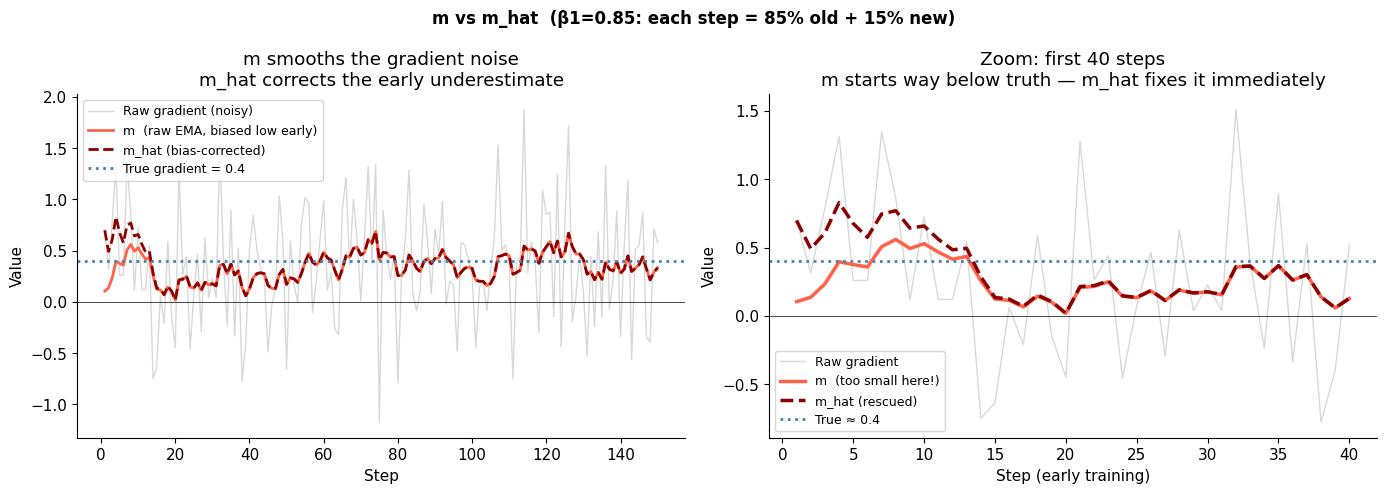

In [13]:
np.random.seed(42)
T = 150
true_grad = 0.4
grads_noisy = true_grad + np.random.randn(T) * 0.6

m_vals, m_hat_vals = [], []
m_i = 0.0
for t, g in enumerate(grads_noisy, start=1):
    m_i = beta1 * m_i + (1 - beta1) * g
    m_vals.append(m_i)
    m_hat_vals.append(m_i / (1 - beta1 ** t))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full trace
ax = axes[0]
ax.plot(range(1, T+1), grads_noisy, alpha=0.3, color='gray', linewidth=1, label='Raw gradient (noisy)')
ax.plot(range(1, T+1), m_vals,     color='tomato',  linewidth=2,   label='m  (raw EMA, biased low early)')
ax.plot(range(1, T+1), m_hat_vals, color='darkred', linewidth=2, linestyle='--', label='m_hat (bias-corrected)')
ax.axhline(true_grad, color='steelblue', linestyle=':', linewidth=2, label=f'True gradient = {true_grad}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Step'); ax.set_ylabel('Value')
ax.set_title('m smooths the gradient noise\nm_hat corrects the early underestimate')
ax.legend(fontsize=9)

# Zoom first 40 steps
ax = axes[1]
Z = 40
ax.plot(range(1, Z+1), grads_noisy[:Z], alpha=0.3, color='gray',   linewidth=1, label='Raw gradient')
ax.plot(range(1, Z+1), m_vals[:Z],     color='tomato',  linewidth=2.5,          label='m  (too small here!)')
ax.plot(range(1, Z+1), m_hat_vals[:Z], color='darkred', linewidth=2.5, linestyle='--', label='m_hat (rescued)')
ax.axhline(true_grad, color='steelblue', linestyle=':', linewidth=2, label=f'True ≈ {true_grad}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Step (early training)'); ax.set_ylabel('Value')
ax.set_title('Zoom: first 40 steps\nm starts way below truth — m_hat fixes it immediately')
ax.legend(fontsize=9)

plt.suptitle('m vs m_hat  (β1=0.85: each step = 85% old + 15% new)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. v and v_hat — Gradient Variance

`v[i] = beta2 × v[i] + (1 − beta2) × grad²`

`v` answers: **"how wild have this parameter's gradients been?"**

- Large gradients → large `v` → large `√v_hat` → divide `m_hat` by something big → **smaller step**
- Small gradients → small `v` → small `√v_hat` → **larger step**

This is the **adaptive** part of Adam. β2 = 0.99 → very slow memory — `v` accumulates over the whole training run.


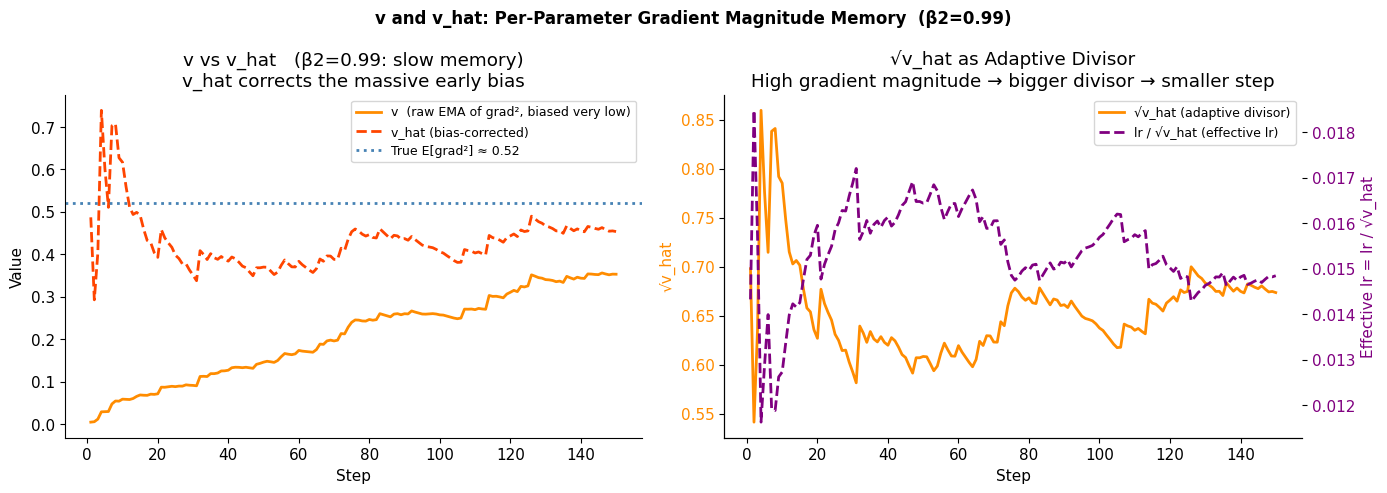

In [14]:
v_vals, v_hat_vals, sqrt_v_hat_vals = [], [], []
v_i = 0.0
for t, g in enumerate(grads_noisy, start=1):
    v_i = beta2 * v_i + (1 - beta2) * g ** 2
    v_hat = v_i / (1 - beta2 ** t)
    v_vals.append(v_i)
    v_hat_vals.append(v_hat)
    sqrt_v_hat_vals.append(math.sqrt(v_hat))

true_e_grad2 = true_grad**2 + 0.6**2   # E[grad²] = mean² + variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# v vs v_hat
ax = axes[0]
ax.plot(range(1, T+1), v_vals,     color='darkorange', linewidth=2,   label='v  (raw EMA of grad², biased very low)')
ax.plot(range(1, T+1), v_hat_vals, color='orangered',  linewidth=2, linestyle='--', label='v_hat (bias-corrected)')
ax.axhline(true_e_grad2, color='steelblue', linestyle=':', linewidth=2, label=f'True E[grad²] ≈ {true_e_grad2:.2f}')
ax.set_xlabel('Step'); ax.set_ylabel('Value')
ax.set_title('v vs v_hat   (β2=0.99: slow memory)\nv_hat corrects the massive early bias')
ax.legend(fontsize=9)

# sqrt(v_hat) as the adaptive divisor
ax = axes[1]
eff_lr_vals = [lr / sv for sv in sqrt_v_hat_vals]
ax2 = ax.twinx()
ax.plot(range(1, T+1),  sqrt_v_hat_vals, color='darkorange', linewidth=2,   label='√v_hat (adaptive divisor)')
ax2.plot(range(1, T+1), eff_lr_vals,     color='purple',     linewidth=2, linestyle='--', label='lr / √v_hat (effective lr)')
ax.set_xlabel('Step'); ax.set_ylabel('√v_hat', color='darkorange')
ax2.set_ylabel('Effective lr = lr / √v_hat', color='purple')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='purple')
ax.set_title('√v_hat as Adaptive Divisor\nHigh gradient magnitude → bigger divisor → smaller step')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.suptitle('v and v_hat: Per-Parameter Gradient Magnitude Memory  (β2=0.99)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. All Together — 6-Panel View of One Parameter

Track all 6 Adam quantities for a single simulated parameter over 300 steps.


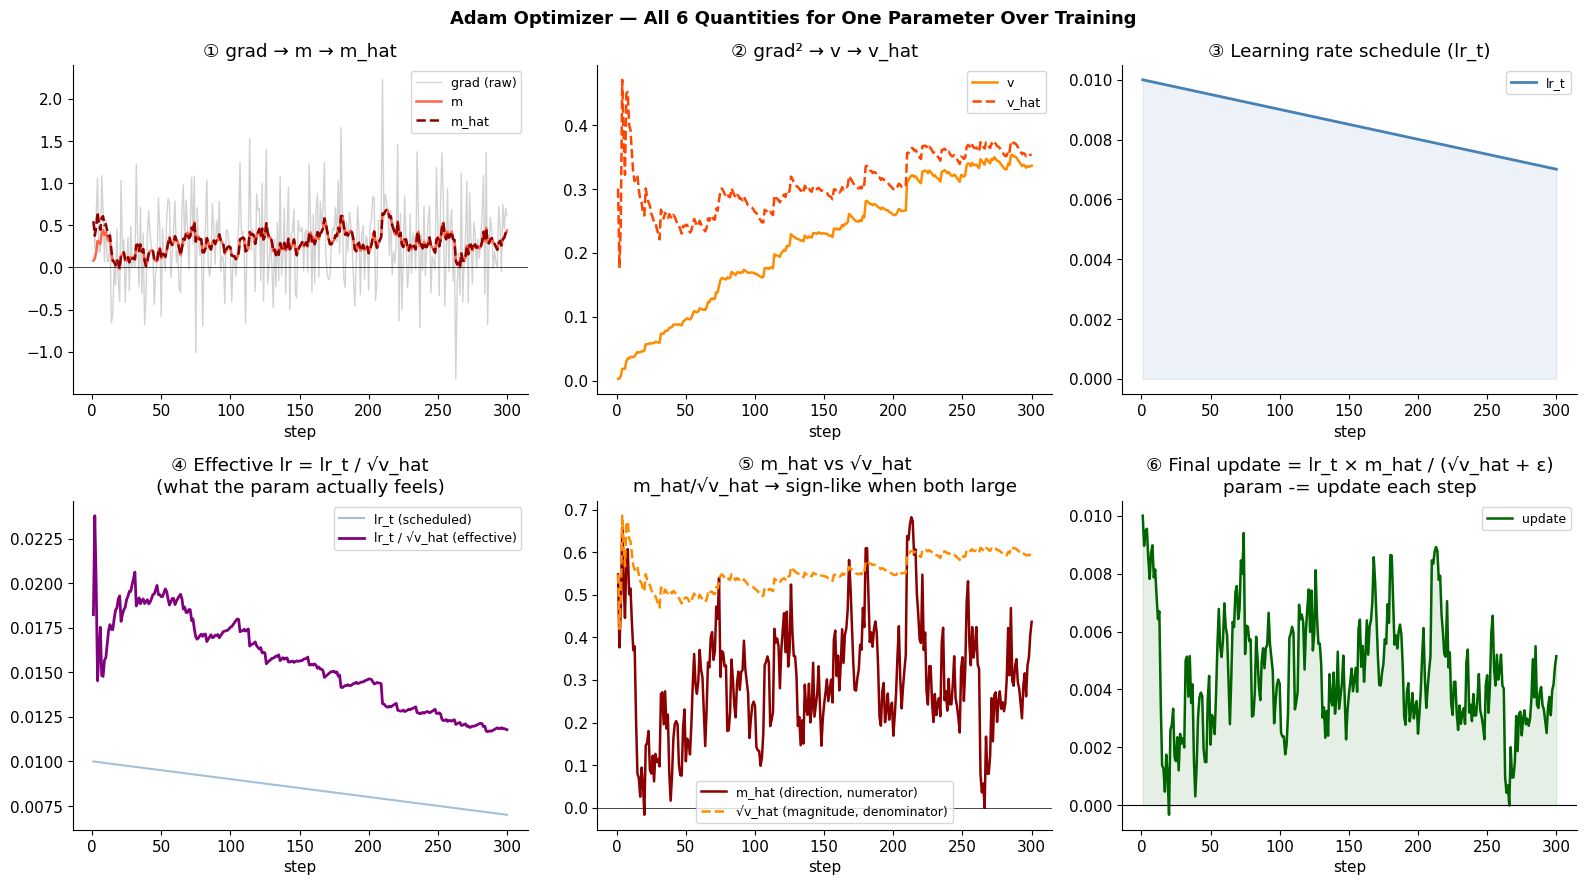

In [15]:
np.random.seed(42)
T2 = 300
true_g2 = 0.3
grads2 = true_g2 + np.random.randn(T2) * 0.5

m_i, v_i = 0.0, 0.0
rec = {k: [] for k in ['grad','m','m_hat','v','v_hat','lr_t','sqrt_v_hat','eff_lr','update']}

for t, g in enumerate(grads2, start=1):
    m_i = beta1 * m_i + (1 - beta1) * g
    v_i = beta2 * v_i + (1 - beta2) * g ** 2
    m_hat = m_i / (1 - beta1 ** t)
    v_hat = v_i / (1 - beta2 ** t)
    sv    = math.sqrt(v_hat)
    lr_t  = lr * (1 - (t - 1) / N)
    rec['grad'].append(g);       rec['m'].append(m_i);      rec['m_hat'].append(m_hat)
    rec['v'].append(v_i);        rec['v_hat'].append(v_hat); rec['sqrt_v_hat'].append(sv)
    rec['lr_t'].append(lr_t);    rec['eff_lr'].append(lr_t / (sv + eps))
    rec['update'].append(lr_t * m_hat / (sv + eps))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
s = range(1, T2 + 1)

# Panel 1
ax = axes[0][0]
ax.plot(s, rec['grad'],  color='gray',    alpha=0.35, linewidth=1, label='grad (raw)')
ax.plot(s, rec['m'],     color='tomato',  linewidth=1.8,            label='m')
ax.plot(s, rec['m_hat'], color='darkred', linewidth=1.8, linestyle='--', label='m_hat')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('① grad → m → m_hat'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Panel 2
ax = axes[0][1]
ax.plot(s, rec['v'],     color='darkorange', linewidth=1.8, label='v')
ax.plot(s, rec['v_hat'], color='orangered',  linewidth=1.8, linestyle='--', label='v_hat')
ax.set_title('② grad² → v → v_hat'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Panel 3
ax = axes[0][2]
ax.plot(s, rec['lr_t'], color='steelblue', linewidth=2, label='lr_t')
ax.fill_between(s, rec['lr_t'], alpha=0.1, color='steelblue')
ax.set_title('③ Learning rate schedule (lr_t)'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Panel 4
ax = axes[1][0]
ax.plot(s, rec['lr_t'],  color='steelblue', linewidth=1.5, alpha=0.5, label='lr_t (scheduled)')
ax.plot(s, rec['eff_lr'], color='purple',    linewidth=2,              label='lr_t / √v_hat (effective)')
ax.set_title('④ Effective lr = lr_t / √v_hat\n(what the param actually feels)'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Panel 5
ax = axes[1][1]
ax.plot(s, rec['m_hat'],     color='darkred',    linewidth=1.8, label='m_hat (direction, numerator)')
ax.plot(s, rec['sqrt_v_hat'], color='darkorange', linewidth=1.8, linestyle='--', label='√v_hat (magnitude, denominator)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('⑤ m_hat vs √v_hat\nm_hat/√v_hat → sign-like when both large'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Panel 6
ax = axes[1][2]
ax.plot(s, rec['update'], color='darkgreen', linewidth=1.8, label='update')
ax.fill_between(s, rec['update'], alpha=0.1, color='darkgreen')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('⑥ Final update = lr_t × m_hat / (√v_hat + ε)\nparam -= update each step'); ax.legend(fontsize=9); ax.set_xlabel('step')

plt.suptitle('Adam Optimizer — All 6 Quantities for One Parameter Over Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. The Adaptive Part — Low vs High Gradient Noise

Two parameters with the **same true gradient** but **different noise levels**.

Adam's `v_hat` penalizes the noisy parameter: bigger `√v_hat` → smaller effective lr → smaller steps.
The noisy parameter is protected — high variance means low trust.


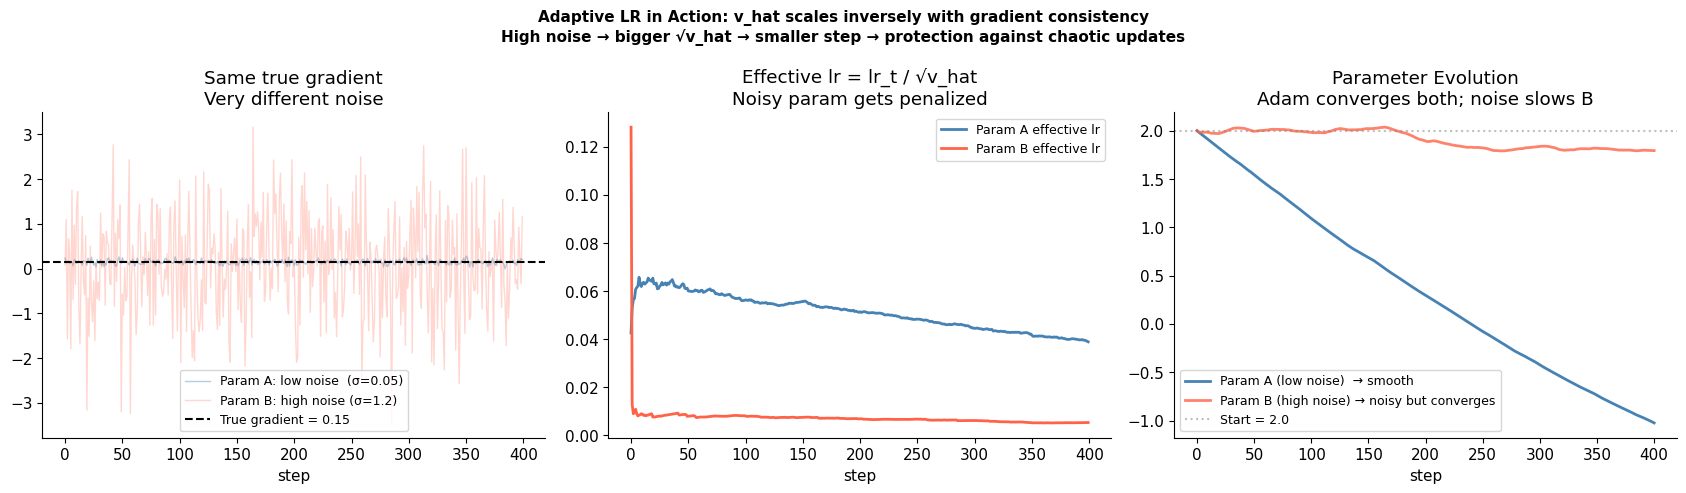

In [16]:
np.random.seed(7)
T3 = 400
true_g3 = 0.15
grad_lo = true_g3 + np.random.randn(T3) * 0.05   # low noise
grad_hi = true_g3 + np.random.randn(T3) * 1.2    # high noise

def adam_run(grads, p0=2.0):
    m_i, v_i, p = 0.0, 0.0, p0
    history, eff_lrs = [p], []
    for t, g in enumerate(grads, start=1):
        m_i = beta1 * m_i + (1 - beta1) * g
        v_i = beta2 * v_i + (1 - beta2) * g ** 2
        m_hat = m_i / (1 - beta1 ** t)
        v_hat = v_i / (1 - beta2 ** t)
        sv    = math.sqrt(v_hat) + eps
        lr_t  = lr * (1 - (t - 1) / N)
        eff_lrs.append(lr_t / sv)
        p -= lr_t * m_hat / sv
        history.append(p)
    return history, eff_lrs

hist_lo, eff_lo = adam_run(grad_lo)
hist_hi, eff_hi = adam_run(grad_hi)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gradient signals
ax = axes[0]
ax.plot(range(T3), grad_lo, alpha=0.4, color='steelblue', linewidth=1, label='Param A: low noise  (σ=0.05)')
ax.plot(range(T3), grad_hi, alpha=0.25, color='tomato',   linewidth=1, label='Param B: high noise (σ=1.2)')
ax.axhline(true_g3, color='black', linestyle='--', linewidth=1.5, label=f'True gradient = {true_g3}')
ax.set_title('Same true gradient\nVery different noise'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Effective lr
ax = axes[1]
ax.plot(range(T3), eff_lo, color='steelblue', linewidth=2, label='Param A effective lr')
ax.plot(range(T3), eff_hi, color='tomato',    linewidth=2, label='Param B effective lr')
ax.set_title('Effective lr = lr_t / √v_hat\nNoisy param gets penalized'); ax.legend(fontsize=9); ax.set_xlabel('step')

# Parameter evolution
ax = axes[2]
ax.plot(range(T3+1), hist_lo, color='steelblue', linewidth=2,       label='Param A (low noise)  → smooth')
ax.plot(range(T3+1), hist_hi, color='tomato',    linewidth=2, alpha=0.8, label='Param B (high noise) → noisy but converges')
ax.axhline(2.0, color='gray', linestyle=':', alpha=0.5, label='Start = 2.0')
ax.set_title('Parameter Evolution\nAdam converges both; noise slows B'); ax.legend(fontsize=9); ax.set_xlabel('step')

plt.suptitle('Adaptive LR in Action: v_hat scales inversely with gradient consistency\nHigh noise → bigger √v_hat → smaller step → protection against chaotic updates', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Key Takeaways

| Quantity | Formula | Intuition |
|----------|---------|-----------|
| `lr_t` | `lr × (1 − step/N)` | Decaying schedule — big steps early, tiny steps late |
| `m` | `β1·m + (1−β1)·grad` | EMA of gradients — raw momentum, biased toward 0 at start |
| `m_hat` | `m / (1 − β1^t)` | Bias-corrected momentum — correct for first ~50 steps |
| `v` | `β2·v + (1−β2)·grad²` | EMA of squared gradients — tracks gradient magnitude, very biased early |
| `v_hat` | `v / (1 − β2^t)` | Bias-corrected variance — needs ~200+ steps to stabilize (β2=0.99) |
| `√v_hat` | `sqrt(v_hat)` | Adaptive divisor — high past gradients → smaller effective step |
| `update` | `lr_t × m_hat / (√v_hat + ε)` | The actual weight change applied each step |

**One-line intuition for Adam:**
> "Take a step in the smoothed gradient direction (`m_hat`), but shrink the step if this parameter has seen wild gradients recently (`v_hat`), and slow down as training progresses (`lr_t`)."


---
## Forward Pass — Visual Walkthrough

Working through the full `gpt()` forward pass for the word **"emma"** (tokens: BOS → e → m → m → a → BOS).

All weights are randomly initialized (same as at the start of training). The structure is what matters here, not the specific values.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(99)
n_embd, n_head, head_dim = 16, 4, 4
vocab_size, block_size = 27, 16

# Random weights matching microgpt init (std=0.08)
std = 0.08
wte    = np.random.randn(vocab_size, n_embd) * std
wpe    = np.random.randn(block_size, n_embd) * std
attn_wq = np.random.randn(n_embd, n_embd) * std
attn_wk = np.random.randn(n_embd, n_embd) * std
attn_wv = np.random.randn(n_embd, n_embd) * std
attn_wo = np.random.randn(n_embd, n_embd) * std
mlp_fc1 = np.random.randn(4 * n_embd, n_embd) * std
mlp_fc2 = np.random.randn(n_embd, 4 * n_embd) * std

# "emma": BOS(26) e(4) m(12) m(12) a(0)  — 5 positions, predicting 5 next tokens
token_ids  = [26, 4, 12, 12, 0]
token_names = ['BOS', 'e', 'm', 'm', 'a']
seq_len = len(token_ids)

def rmsnorm(x):
    return x / np.sqrt(np.mean(x**2) + 1e-5)

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

# Build embeddings for every position
tok_embs = np.stack([wte[tid] for tid in token_ids])   # [5, 16]
pos_embs = np.stack([wpe[i]   for i   in range(seq_len)])  # [5, 16]
x_raw    = tok_embs + pos_embs                          # [5, 16]
x_norm   = np.stack([rmsnorm(x) for x in x_raw])       # [5, 16] after rmsnorm

# Project Q, K, V for every position
Q = x_norm @ attn_wq.T   # [5, 16]
K = x_norm @ attn_wk.T   # [5, 16]
V = x_norm @ attn_wv.T   # [5, 16]

# Split into heads: [5, n_head, head_dim]
Q_h = Q.reshape(seq_len, n_head, head_dim)
K_h = K.reshape(seq_len, n_head, head_dim)
V_h = V.reshape(seq_len, n_head, head_dim)

# Compute full causal attention weight matrix per head: [n_head, seq_len, seq_len]
attn_scores = np.einsum('ihd,jhd->hij', Q_h, K_h) / np.sqrt(head_dim)  # [n_head, seq, seq]
# Causal mask: upper triangle = -inf
causal_mask = np.triu(np.full((seq_len, seq_len), -1e9), k=1)
attn_scores_masked = attn_scores + causal_mask[None, :, :]
# Each token t can only attend to positions 0..t, so sub-arrays have different lengths — store as list
attn_weights = [[softmax(attn_scores_masked[h, t, :t+1])
                 for t in range(seq_len)] for h in range(n_head)]
# Pad weights to [n_head, seq_len, seq_len] for heatmap
attn_w_full = np.zeros((n_head, seq_len, seq_len))
for h in range(n_head):
    for t in range(seq_len):
        attn_w_full[h, t, :t+1] = attn_weights[h][t]

print("Setup done. Sequence:", token_names)
print(f"  tok_embs: {tok_embs.shape}, pos_embs: {pos_embs.shape}")
print(f"  Q: {Q.shape}, K: {K.shape}, V: {V.shape}")
print(f"  attn_w_full: {attn_w_full.shape}  [n_head, seq_pos, attended_pos]")

Setup done. Sequence: ['BOS', 'e', 'm', 'm', 'a']
  tok_embs: (5, 16), pos_embs: (5, 16)
  Q: (5, 16), K: (5, 16), V: (5, 16)
  attn_w_full: (4, 5, 5)  [n_head, seq_pos, attended_pos]


## Stage 1 — Embeddings: Token + Position → x

`x = wte[token_id] + wpe[pos_id]` then `rmsnorm(x)`

Each token and position gets its own 16-dim vector from the lookup tables.
Adding them fuses *what* (token) and *where* (position) into a single vector.
RMSNorm resets the overall magnitude to ~1 before attention.


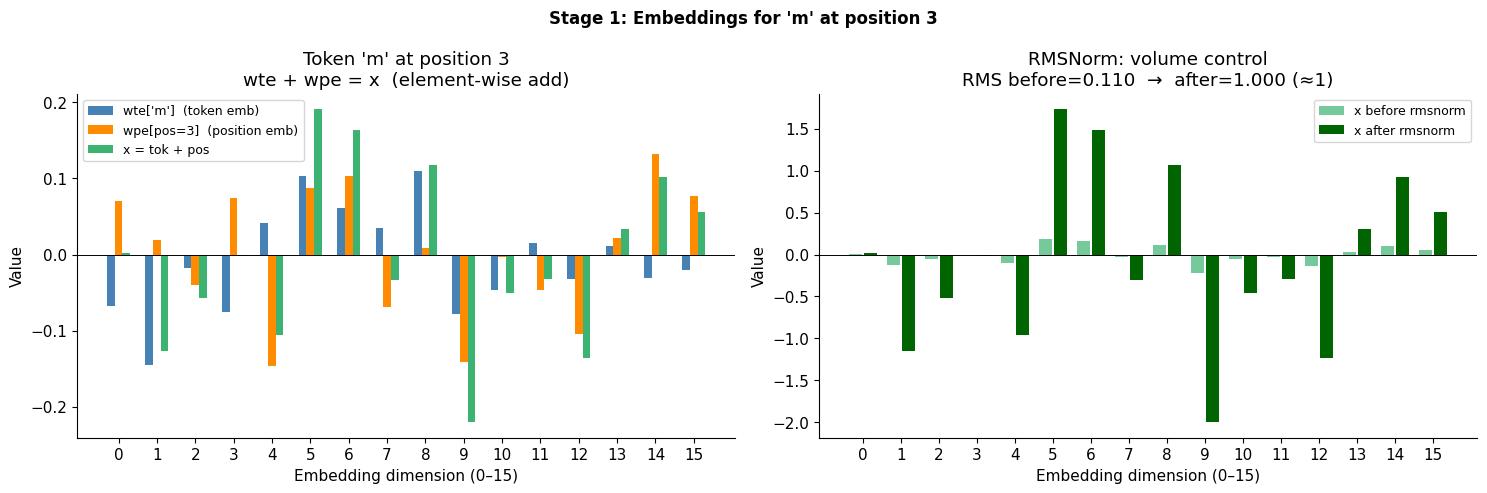

In [23]:
# Pick position 3 (second 'm') as the example
pos = 3
tok = token_names[pos]
t_emb = tok_embs[pos]
p_emb = pos_embs[pos]
x_sum = x_raw[pos]
x_n   = x_norm[pos]

dims = np.arange(n_embd)
w = 0.2  # bar width

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: three bars per dimension — tok, pos, sum
ax = axes[0]
ax.bar(dims - w, t_emb, width=w, color='steelblue',  label=f"wte['{tok}']  (token emb)")
ax.bar(dims,     p_emb, width=w, color='darkorange',  label=f'wpe[pos={pos}]  (position emb)')
ax.bar(dims + w, x_sum, width=w, color='mediumseagreen', label='x = tok + pos')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Embedding dimension (0–15)')
ax.set_ylabel('Value')
ax.set_title(f"Token '{tok}' at position {pos}\nwte + wpe = x  (element-wise add)")
ax.legend(fontsize=9)
ax.set_xticks(dims)

# Right: before vs after RMSNorm
ax = axes[1]
ax.bar(dims - 0.2, x_sum, width=0.35, color='mediumseagreen', alpha=0.7, label='x before rmsnorm')
ax.bar(dims + 0.2, x_n,   width=0.35, color='darkgreen',       label='x after rmsnorm')
ax.axhline(0, color='black', linewidth=0.7)
# Annotate the scale change
rms_before = np.sqrt(np.mean(x_sum**2))
rms_after  = np.sqrt(np.mean(x_n**2))
ax.set_title(f'RMSNorm: volume control\nRMS before={rms_before:.3f}  →  after={rms_after:.3f} (≈1)')
ax.set_xlabel('Embedding dimension (0–15)')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.set_xticks(dims)

plt.suptitle(f"Stage 1: Embeddings for '{tok}' at position {pos}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Embeddings for the Full Sequence

Each row is one token's 16-dim embedding vector after rmsnorm.
Every token looks different — different rows in the wte and wpe lookup tables.


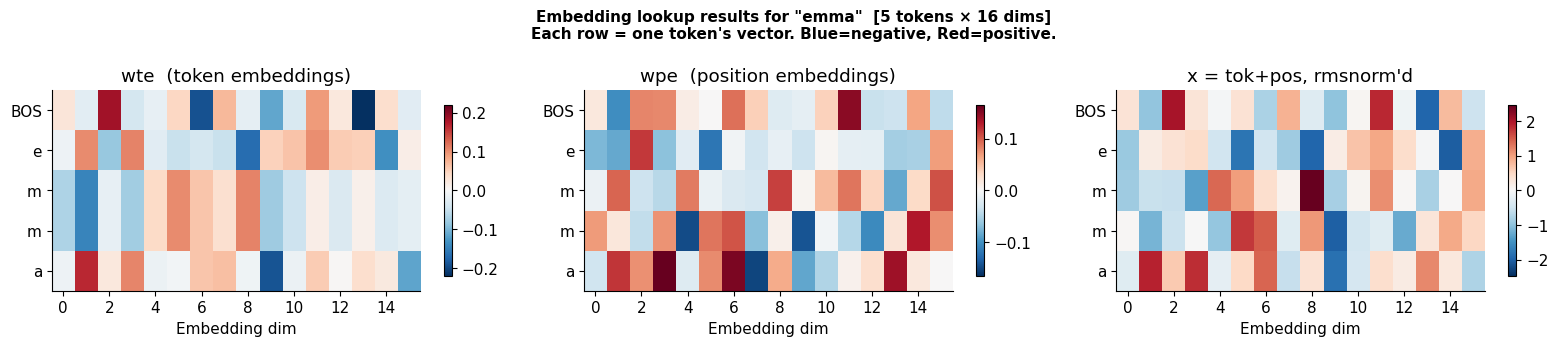

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

cmap = 'RdBu_r'
for ax, mat, title in zip(axes,
        [tok_embs, pos_embs, x_norm],
        ['wte  (token embeddings)', 'wpe  (position embeddings)', "x = tok+pos, rmsnorm'd"]):
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(token_names)
    ax.set_xlabel('Embedding dim')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle('Embedding lookup results for "emma"  [5 tokens × 16 dims]\nEach row = one token\'s vector. Blue=negative, Red=positive.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 2 — Attention: Q, K, V Projections

The same `x` vector is linearly projected three different ways:
- **Q (Query)**: "what am I looking for?"
- **K (Key)**: "what do I contain / advertise?"
- **V (Value)**: "what will I give if selected?"

All three start from the same input — what differs is the learned weight matrix.


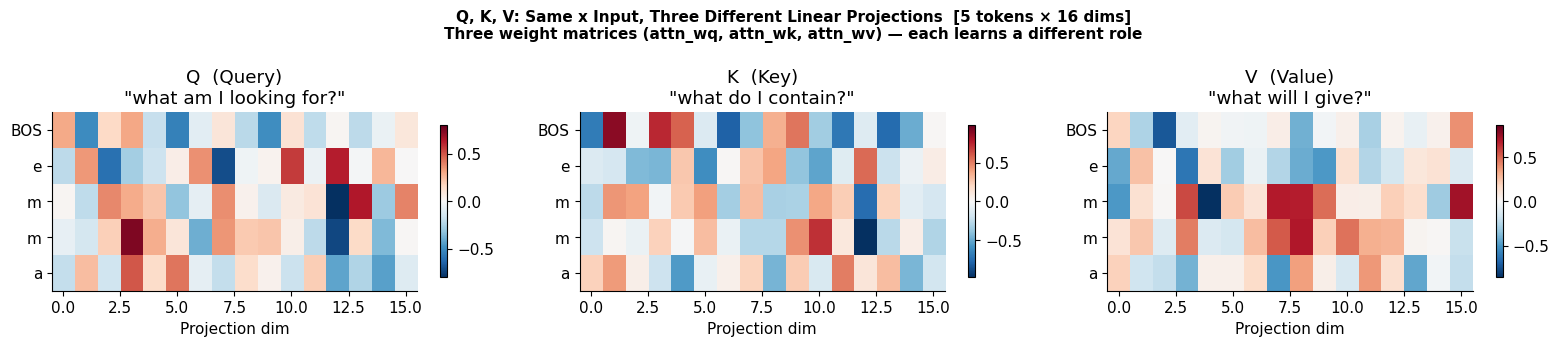

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
cmap = 'RdBu_r'
labels = ['Q  (Query)\n"what am I looking for?"',
          'K  (Key)\n"what do I contain?"',
          'V  (Value)\n"what will I give?"']
colors_bar = ['tomato', 'steelblue', 'mediumseagreen']

for ax, mat, label, col in zip(axes, [Q, K, V], labels, colors_bar):
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(token_names)
    ax.set_xlabel('Projection dim')
    ax.set_title(label)
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle('Q, K, V: Same x Input, Three Different Linear Projections  [5 tokens × 16 dims]\n'
             'Three weight matrices (attn_wq, attn_wk, attn_wv) — each learns a different role',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Multi-Head Split — 16 dims → 4 × 4 dims

After computing the full 16-dim Q (and K, V), we carve it into 4 slices of 4 dims each.
Each slice = one head's Q vector. The heads then run **independently in parallel**.

Head 0 uses dims 0–3, Head 1 uses dims 4–7, Head 2 uses dims 8–11, Head 3 uses dims 12–15.


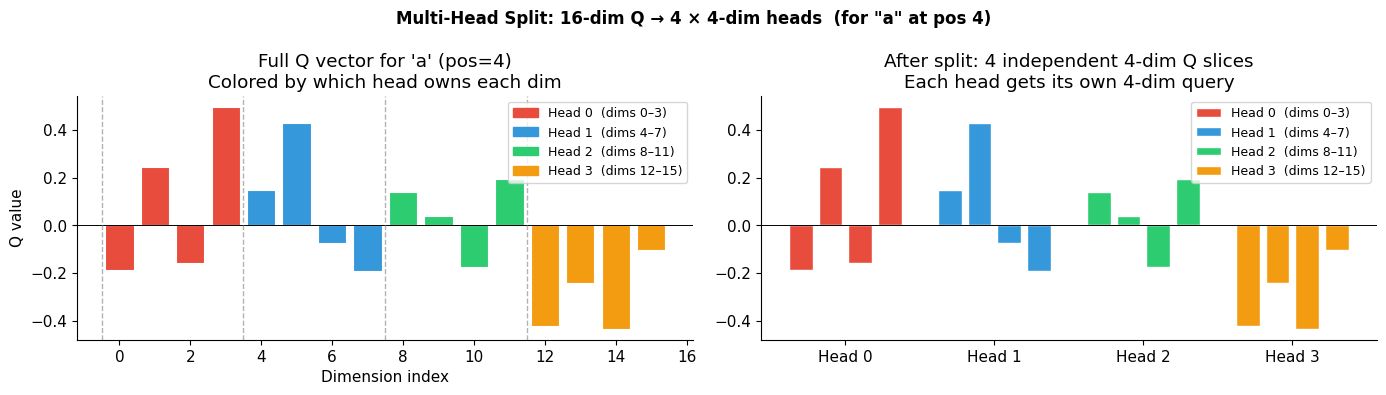

In [26]:
# Show the split for position 4 ('a') — the last token that has seen the whole sequence
pos_show = 4
q_full = Q[pos_show]   # 16-dim
head_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
head_labels = [f'Head {h}  (dims {h*4}–{h*4+3})' for h in range(n_head)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full Q vector, colored by which head owns each dim
ax = axes[0]
bar_colors = [head_colors[d // head_dim] for d in range(n_embd)]
bars = ax.bar(range(n_embd), q_full, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.7)
for h in range(n_head):
    ax.axvline(h * head_dim - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Dimension index')
ax.set_ylabel('Q value')
ax.set_title(f"Full Q vector for '{token_names[pos_show]}' (pos={pos_show})\nColored by which head owns each dim")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=head_colors[h], label=head_labels[h]) for h in range(n_head)], fontsize=9)

# Right: 4 separate head slices side by side
ax = axes[1]
x_pos = np.arange(head_dim)
for h in range(n_head):
    offset = h * (head_dim + 1)
    ax.bar(x_pos + offset, Q_h[pos_show, h], color=head_colors[h], label=head_labels[h], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.7)
tick_positions = [h * (head_dim + 1) + head_dim / 2 - 0.5 for h in range(n_head)]
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'Head {h}' for h in range(n_head)])
ax.set_title(f"After split: 4 independent 4-dim Q slices\nEach head gets its own 4-dim query")
ax.legend(fontsize=9)

plt.suptitle(f'Multi-Head Split: 16-dim Q → 4 × 4-dim heads  (for "{token_names[pos_show]}" at pos {pos_show})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Attention Weight Matrix — All 4 Heads

For each token (row), how much attention does it pay to each past token (column)?

**Causal masking**: a token can only attend to itself and earlier positions — never to the future.
This is why the upper triangle is always 0 (blank).

Each head independently develops its own pattern. Trained heads learn different specializations:
head 0 might track vowels, head 1 might track position, etc. These are random weights — shape is what matters.


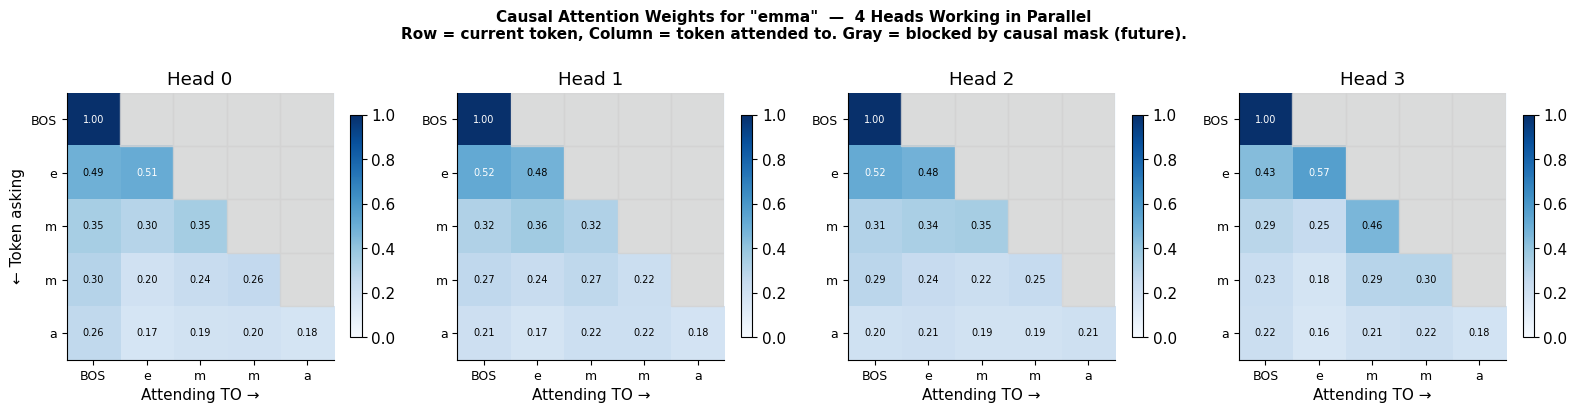

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmap_attn = plt.cm.Blues

for h, ax in enumerate(axes):
    im = ax.imshow(attn_w_full[h], cmap=cmap_attn, vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(seq_len)); ax.set_xticklabels(token_names, fontsize=9)
    ax.set_yticks(range(seq_len)); ax.set_yticklabels(token_names, fontsize=9)
    ax.set_xlabel('Attending TO →')
    if h == 0: ax.set_ylabel('← Token asking')
    ax.set_title(f'Head {h}')

    # Annotate weights on cells
    for i in range(seq_len):
        for j in range(i + 1):
            w = attn_w_full[h, i, j]
            ax.text(j, i, f'{w:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if w > 0.5 else 'black')

    # Gray out future (causal mask)
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         fill=True, color='lightgray', alpha=0.8))

    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Causal Attention Weights for "emma"  —  4 Heads Working in Parallel\n'
             'Row = current token, Column = token attended to. Gray = blocked by causal mask (future).',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Per-Head Attention — What Is 'a' (the Last Token) Looking At?

For the final token 'a' at position 4, each head independently decides which past tokens to attend to.
This is the bar-chart view of the last row of each head's attention matrix.


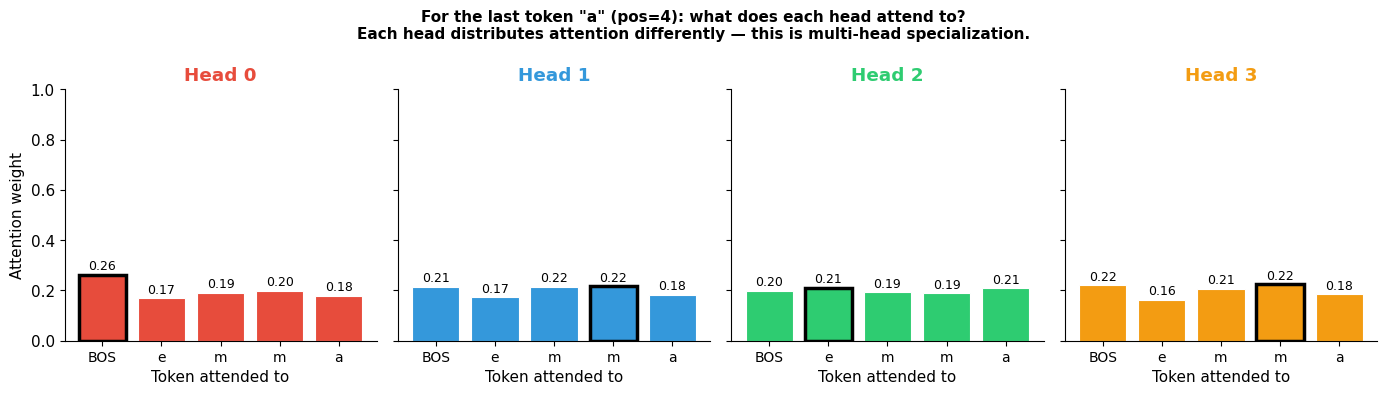

In [28]:
last_pos = seq_len - 1   # 'a' at position 4
head_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for h, ax in enumerate(axes):
    weights = attn_w_full[h, last_pos]   # attention weights this head places on each past token
    bars = ax.bar(range(seq_len), weights, color=head_colors[h], edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(token_names, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'Head {h}', color=head_colors[h], fontweight='bold')
    ax.set_xlabel('Token attended to')
    if h == 0: ax.set_ylabel('Attention weight')
    # Annotate each bar
    for i, w in enumerate(weights):
        if w > 0.01:
            ax.text(i, w + 0.02, f'{w:.2f}', ha='center', fontsize=9)
    # Mark the most attended token
    top = int(np.argmax(weights))
    bars[top].set_edgecolor('black')
    bars[top].set_linewidth(2.5)

plt.suptitle(f'For the last token "a" (pos={last_pos}): what does each head attend to?\n'
             'Each head distributes attention differently — this is multi-head specialization.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Value Blending — What Information Flows Into the Output

After computing attention weights, each head blends the **value vectors** of all past tokens.

`head_out = sum(attn_weight[t] * V[t]  for each past t)`

This is a weighted average of value vectors. Tokens with high attention weight contribute more of their value.


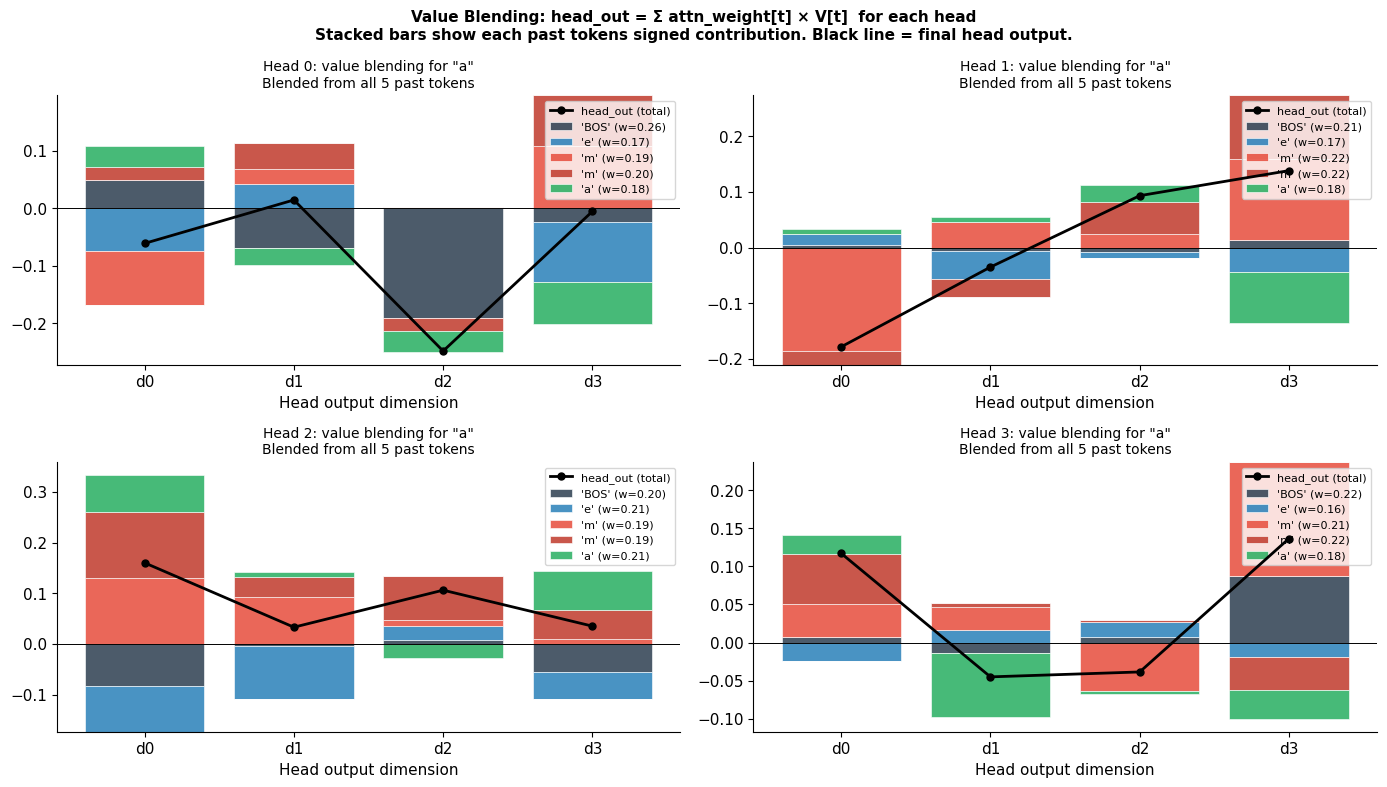

In [30]:
last_pos = seq_len - 1
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for h, ax in enumerate(axes.flat):
    weights = attn_w_full[h, last_pos]   # [seq_len] — how much each token contributes
    v_h = V_h[:, h, :]                  # [seq_len, head_dim] — value vectors per token
    head_out = weights @ v_h             # [head_dim] — the blended output

    # Stacked bar: contribution of each token to each output dimension
    bottoms = np.zeros(head_dim)
    neg_bottoms = np.zeros(head_dim)
    colors_t = ['#2c3e50', '#2980b9', '#e74c3c', '#c0392b', '#27ae60']
    dims = np.arange(head_dim)

    for t in range(seq_len):
        contribution = weights[t] * v_h[t]  # [head_dim]
        pos_part = np.clip(contribution, 0, None)
        neg_part = np.clip(contribution, None, 0)
        ax.bar(dims, pos_part, bottom=bottoms, color=colors_t[t],
               alpha=0.85, label=f"'{token_names[t]}' (w={weights[t]:.2f})", edgecolor='white', linewidth=0.5)
        ax.bar(dims, neg_part, bottom=neg_bottoms, color=colors_t[t], alpha=0.85, edgecolor='white', linewidth=0.5)
        bottoms += pos_part
        neg_bottoms += neg_part

    ax.plot(dims, head_out, 'k-o', markersize=5, linewidth=2, zorder=10, label='head_out (total)')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'Head {h}: value blending for "a"\nBlended from all {seq_len} past tokens', fontsize=10)
    ax.set_xticks(dims)
    ax.set_xticklabels([f'd{i}' for i in range(head_dim)])
    ax.set_xlabel('Head output dimension')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Value Blending: head_out = Σ attn_weight[t] × V[t]  for each head\n'
             'Stacked bars show each past tokens signed contribution. Black line = final head output.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 3 — MLP Block: Expand → ReLU → Compress

After attention, each token independently runs through a two-layer MLP:
1. **fc1**: 16 → 64 (expand to wide thinking space)
2. **ReLU**: kill negatives (creates sparsity — only some neurons fire)
3. **fc2**: 64 → 16 (compress back to highway)

**Attention = communication** (tokens looking at each other).  
**MLP = computation** (each token thinking alone in a wider space).


/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/2178814519.py:3: RuntimeWarning: divide by zero encountered in matmul
  h1    = mlp_fc1 @ x_in           # [64] — after fc1 (expand)
/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/2178814519.py:3: RuntimeWarning: overflow encountered in matmul
  h1    = mlp_fc1 @ x_in           # [64] — after fc1 (expand)
/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/2178814519.py:3: RuntimeWarning: invalid value encountered in matmul
  h1    = mlp_fc1 @ x_in           # [64] — after fc1 (expand)
/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/2178814519.py:5: RuntimeWarning: divide by zero encountered in matmul
  out   = mlp_fc2 @ h1_relu        # [16] — after fc2 (compress)
/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/2178814519.py:5: RuntimeWarning: overflow encountered in matmul
  out   = mlp_fc2 @ h1_relu        # [16] — after fc2 (compress)
/var/folders/00/vf7

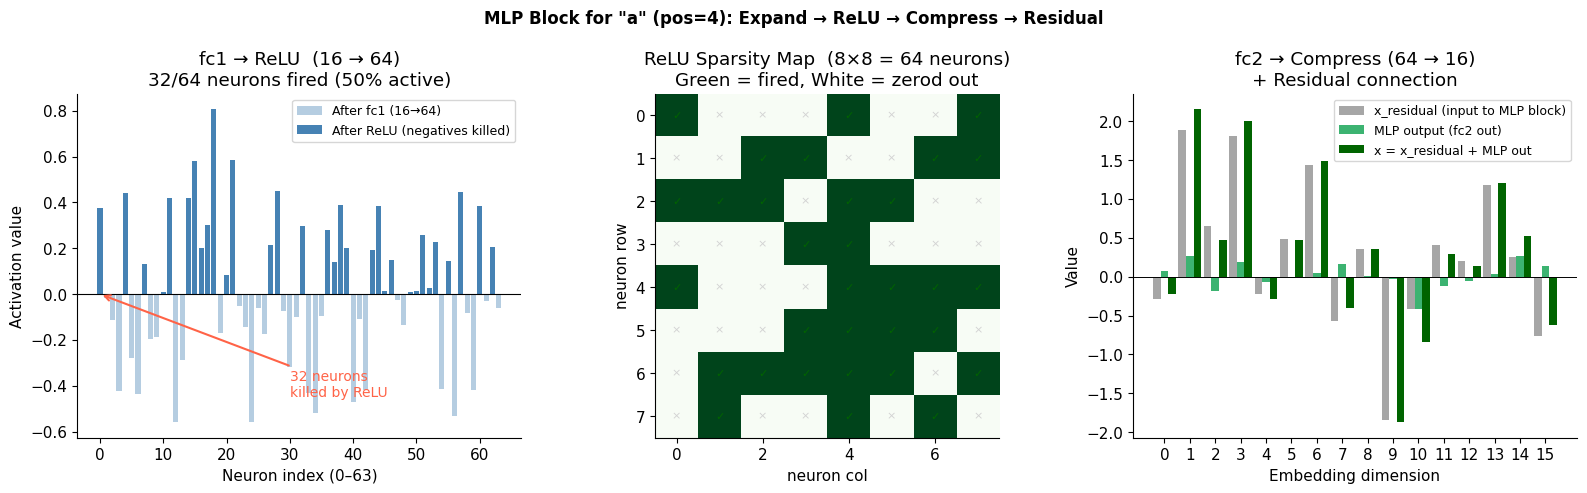

In [32]:
# Run MLP for position 4 ('a')
x_in  = x_norm[last_pos]         # 16-dim input
h1    = mlp_fc1 @ x_in           # [64] — after fc1 (expand)
h1_relu = np.maximum(0, h1)      # [64] — after ReLU
out   = mlp_fc2 @ h1_relu        # [16] — after fc2 (compress)

fired = (h1 > 0)                 # which neurons fired
n_fired = fired.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: fc1 output (64 dims) — before and after ReLU
ax = axes[0]
dims64 = np.arange(64)
ax.bar(dims64, h1,      color='steelblue', alpha=0.4, label='After fc1 (16→64)', linewidth=0)
ax.bar(dims64, h1_relu, color='steelblue', alpha=1.0, label='After ReLU (negatives killed)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Neuron index (0–63)')
ax.set_ylabel('Activation value')
ax.set_title(f'fc1 → ReLU  (16 → 64)\n{n_fired}/64 neurons fired ({n_fired/64*100:.0f}% active)')
ax.legend(fontsize=9)
ax.annotate(f'{64 - n_fired} neurons\nkilled by ReLU', xy=(0, 0), xytext=(30, h1.min() * 0.8),
            fontsize=10, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))

# Middle: which neurons fired (binary map)
ax = axes[1]
ax.imshow(fired.reshape(8, 8), cmap='Greens', aspect='equal', vmin=0, vmax=1)
ax.set_title(f'ReLU Sparsity Map  (8×8 = 64 neurons)\nGreen = fired, White = zerod out')
ax.set_xlabel('neuron col'); ax.set_ylabel('neuron row')
for i in range(8):
    for j in range(8):
        ax.text(j, i, '✓' if fired[i*8+j] else '×', ha='center', va='center',
                fontsize=8, color='darkgreen' if fired[i*8+j] else 'lightgray')

# Right: fc2 output vs input (both 16-dim) — the residual connection
ax = axes[2]
w = 0.3
dims16 = np.arange(n_embd)
ax.bar(dims16 - w, x_in,           width=w, color='gray',         alpha=0.7, label='x_residual (input to MLP block)')
ax.bar(dims16,     out,             width=w, color='mediumseagreen', label='MLP output (fc2 out)')
ax.bar(dims16 + w, x_in + out,     width=w, color='darkgreen',    label='x = x_residual + MLP out')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Value')
ax.set_title('fc2 → Compress (64 → 16)\n+ Residual connection')
ax.legend(fontsize=9)
ax.set_xticks(dims16)

plt.suptitle('MLP Block for "a" (pos=4): Expand → ReLU → Compress → Residual',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Full Forward Pass — Dimension Flow Diagram

Tracking how a single token's vector changes shape at every stage.


/var/folders/00/vf7xj1vd2mn8bd1xj27sr8ch0000gn/T/ipykernel_74901/352700454.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((i * 3.2, -0.75), 0.35, 0.35, color=color, linewidth=1, edgecolor='gray'))


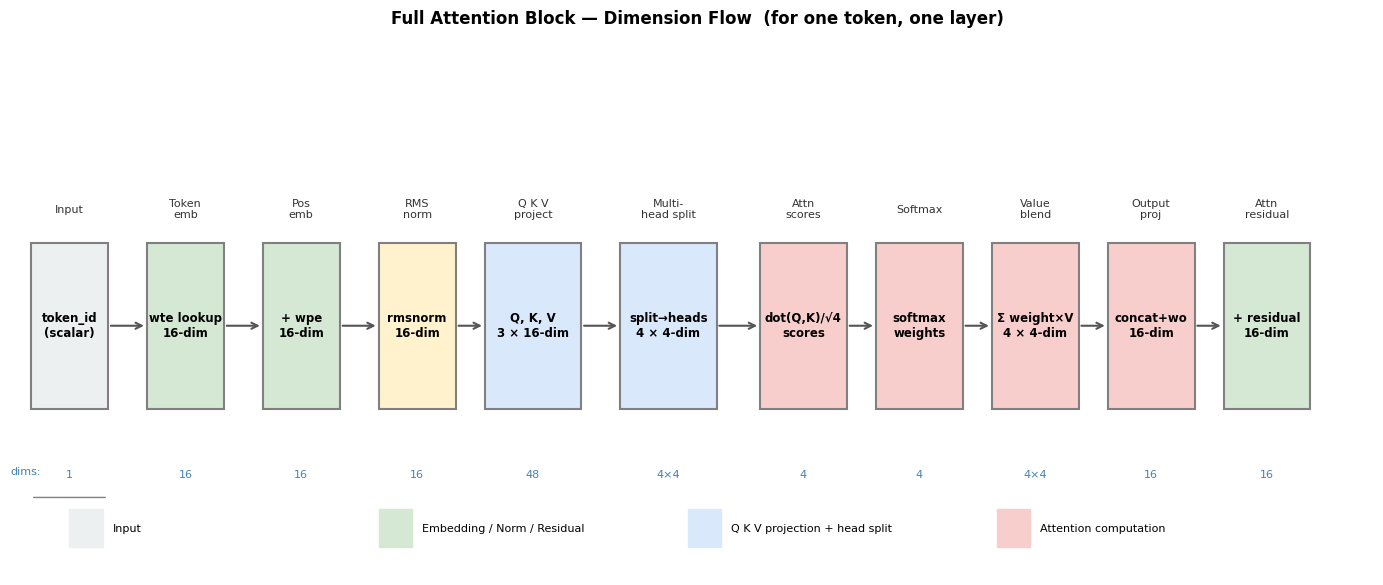

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(-0.5, 13.5)
ax.set_ylim(-1, 4)
ax.axis('off')

# Stages: (x_pos, label, width, height, color)
stages = [
    (0,   "token_id\n(scalar)",        0.8, 1.5, '#ecf0f1'),
    (1.2, "wte lookup\n16-dim",        0.8, 1.5, '#d5e8d4'),
    (2.4, "+ wpe\n16-dim",             0.8, 1.5, '#d5e8d4'),
    (3.6, "rmsnorm\n16-dim",           0.8, 1.5, '#fff2cc'),
    (4.8, "Q, K, V\n3 × 16-dim",       1.0, 1.5, '#dae8fc'),
    (6.2, "split→heads\n4 × 4-dim",    1.0, 1.5, '#dae8fc'),
    (7.6, "dot(Q,K)/√4\nscores",        0.9, 1.5, '#f8cecc'),
    (8.8, "softmax\nweights",           0.9, 1.5, '#f8cecc'),
    (10.0,"Σ weight×V\n4 × 4-dim",      0.9, 1.5, '#f8cecc'),
    (11.2,"concat+wo\n16-dim",          0.9, 1.5, '#f8cecc'),
    (12.4,"+ residual\n16-dim",         0.9, 1.5, '#d5e8d4'),
]

for x, label, w, h, color in stages:
    rect = plt.Rectangle((x - w/2, 0.5), w, h, linewidth=1.5,
                          edgecolor='gray', facecolor=color)
    ax.add_patch(rect)
    ax.text(x, 1.25, label, ha='center', va='center', fontsize=8.5, fontweight='bold')

# Arrows between stages
for i in range(len(stages) - 1):
    x0 = stages[i][0]   + stages[i][2]   / 2
    x1 = stages[i+1][0] - stages[i+1][2] / 2
    ax.annotate('', xy=(x1, 1.25), xytext=(x0, 1.25),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

# Stage labels above
stage_names = ['Input', 'Token\nemb', 'Pos\nemb', 'RMS\nnorm',
               'Q K V\nproject', 'Multi-\nhead split',
               'Attn\nscores', 'Softmax', 'Value\nblend',
               'Output\nproj', 'Attn\nresidual']
for i, (x, *_) in enumerate(stages):
    ax.text(x, 2.3, stage_names[i], ha='center', va='center', fontsize=8, color='#333')

# Section brackets
ax.annotate('', xy=(0.4, -0.3), xytext=(-0.4, -0.3),
            arrowprops=dict(arrowstyle='-', color='gray'))

# Dim labels below
dim_info = ['1', '16', '16', '16', '48', '4×4', '4', '4', '4×4', '16', '16']
for i, (x, *_) in enumerate(stages):
    ax.text(x, -0.1, dim_info[i], ha='center', va='center', fontsize=8, color='steelblue')

ax.text(-0.3, -0.1, 'dims:', ha='right', fontsize=8, color='steelblue')

# Color legend
legend_items = [
    ('#ecf0f1', 'Input'),
    ('#d5e8d4', 'Embedding / Norm / Residual'),
    ('#dae8fc', 'Q K V projection + head split'),
    ('#f8cecc', 'Attention computation'),
]
for i, (color, label) in enumerate(legend_items):
    ax.add_patch(plt.Rectangle((i * 3.2, -0.75), 0.35, 0.35, color=color, linewidth=1, edgecolor='gray'))
    ax.text(i * 3.2 + 0.45, -0.58, label, fontsize=8, va='center')

ax.set_title('Full Attention Block — Dimension Flow  (for one token, one layer)',
             fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## Multi-Head Attention — Key Takeaways

| Step | Operation | Input → Output | Why |
|------|-----------|---------------|-----|
| 1 | `wte[id] + wpe[pos]` | scalar → 16-dim | Fuse *what* (token) + *where* (position) |
| 2 | `rmsnorm(x)` | 16 → 16 | Stabilize magnitude before attention |
| 3 | `x @ wq.T`, `x @ wk.T`, `x @ wv.T` | 16 → 16 (×3) | Project into Q/K/V spaces |
| 4 | `Q.reshape(4, 4)` | 16 → 4×4 | Split into 4 independent heads |
| 5 | `dot(q_h, k_h) / √4` | 4-dim dot → scalar | Score: how relevant is past token t? |
| 6 | `softmax(scores)` | scores → weights (sum=1) | Turn scores into probability distribution |
| 7 | `Σ weight[t] × v_h[t]` | weights + values → 4-dim | Blend: gather information from the past |
| 8 | `concat heads → attn_wo` | 4×4 → 16 | Mix what all heads learned |
| 9 | `x = x + attn_out` | residual add | Keep original identity + add context |

**The key insight:** Steps 5–7 run independently per head (4 heads in parallel). Each head can specialize:
one tracks vowels, one tracks position, one tracks repetition — all discovered through gradient descent.
